## Ejemplo 1. descomposición y pronóstico de series de tiempo desempleo Colombia
- Utilizaremos datos de desempleo de Colombia para realizar la descomposición clásica y por STL
- Realizar el pronóstico de la serie para h=12 usando la descomposición.

In [1]:
# Librerias
install.packages(c("tidyverse", "tsibble", "feasts", "fable"))

# Librerias
library(tidyverse)
library(tsibble)
library(feasts)
library(fable)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘quadprog’, ‘BH’, ‘progressr’, ‘ggdist’, ‘warp’, ‘numDeriv’, ‘anytime’, ‘fabletools’, ‘slider’, ‘ggtime’, ‘distributional’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘tsibble’


The following object is masked from ‘package:lubridate’:

    interval


The following objects are masked from ‘package:base’:

    intersect, setdiff, union


Loading required package: fabletools



In [2]:
# Leer los datos desde github
desempleo <- read_csv2("https://raw.githubusercontent.com/fersalme/series-tiempo-econometria/refs/heads/main/data/Mercado%20laboral%20y%20poblaci%C3%B3n.csv")
colnames(desempleo) <- c("periodo", "tasa_desempleo", "tasa_ocupacion")
head(desempleo)


ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

Rows: 301 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
dbl  (2): Tasa de desempleo - total nacional, Tasa de ocupación - total naci...
date (1): Periodo(MMM, AAAA)

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


periodo,tasa_desempleo,tasa_ocupacion
<date>,<dbl>,<dbl>
2001-01-31,16.62,57.58
2001-02-28,17.43,56.93
2001-03-31,15.81,57.57
2001-04-30,14.52,55.76
2001-05-31,14.04,56.23
2001-06-30,15.31,56.18


In [3]:
# Numero de registros
cat("Número de observaciones serie desempleo : ", nrow(desempleo))
cat("\nTemporalidad de la serie : ", range(year(desempleo$periodo)))
cat("\nTemporalidad fechas de la serie :", range(desempleo$periodo))

Número de observaciones serie desempleo :  301
Temporalidad de la serie :  2001 2026
Temporalidad fechas de la serie : 11353 20484

In [4]:
# Ajustar la temporalidad de los periodos
desempleo <- desempleo |>
  mutate(periodo = yearmonth(periodo)) |>
  as_tsibble(index = periodo) |>
  select(-tasa_ocupacion)

head(desempleo)

periodo,tasa_desempleo
<mth>,<dbl>
2001 Jan,16.62
2001 Feb,17.43
2001 Mar,15.81
2001 Apr,14.52
2001 May,14.04
2001 Jun,15.31


Plot variable not specified, automatically selected `.vars = tasa_desempleo`


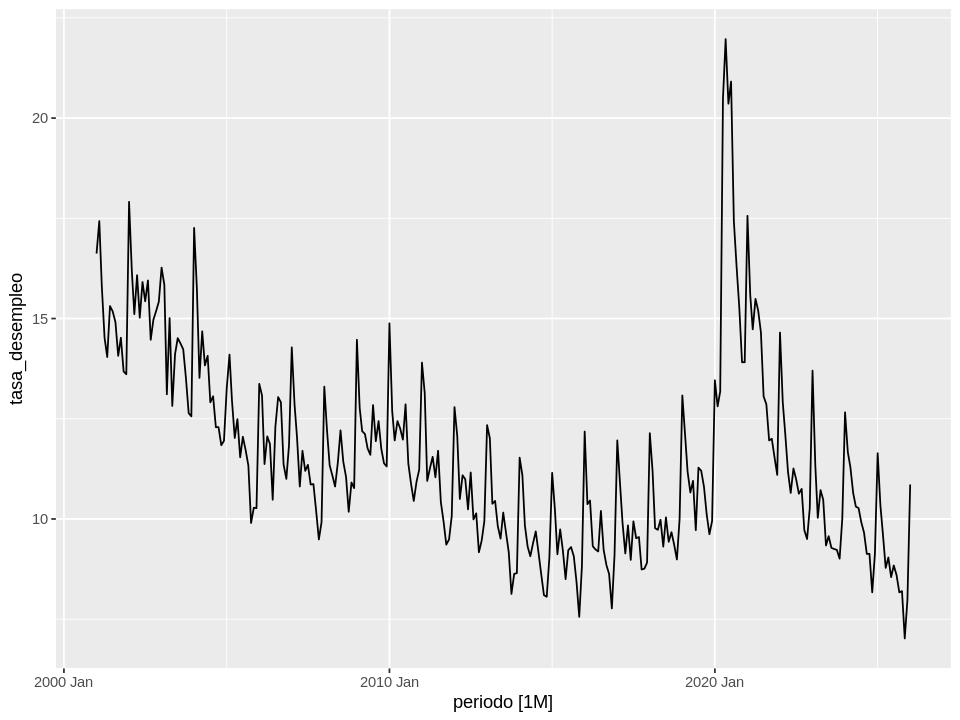

In [15]:
# tamaño de los graficos
options(repr.plot.width = 8, repr.plot.height = 6)

# grafico de la serie
autoplot(desempleo)

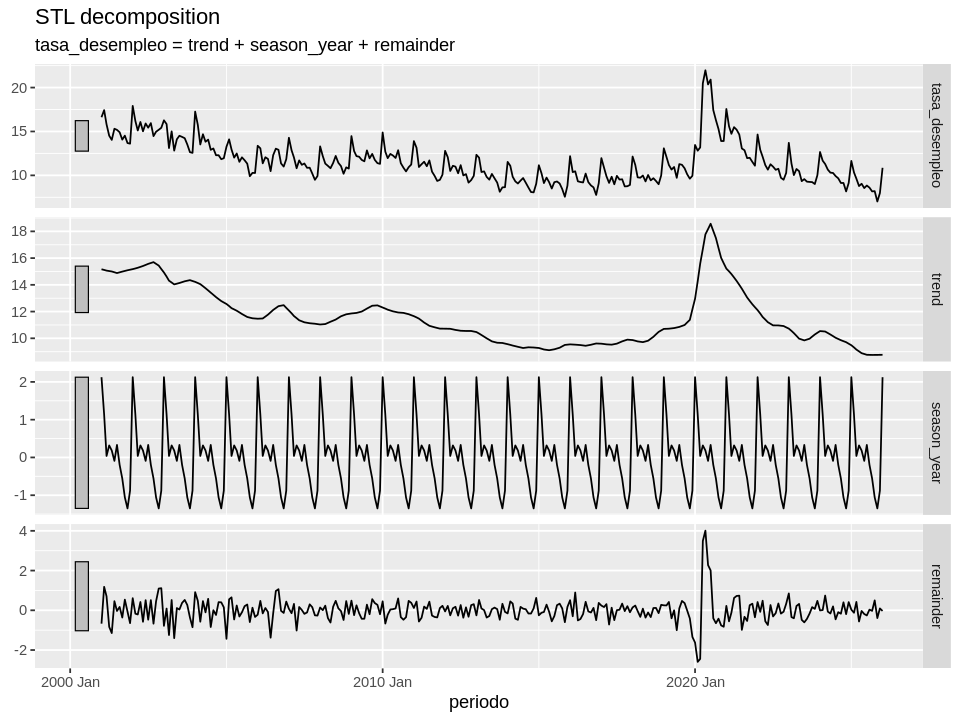

In [16]:
# Descomposicion STL de la serie
desempleo |>
  model(
    STL(tasa_desempleo ~ trend(window = 13) + season(window = "periodic"))
  ) |>
  components() |>
  autoplot()


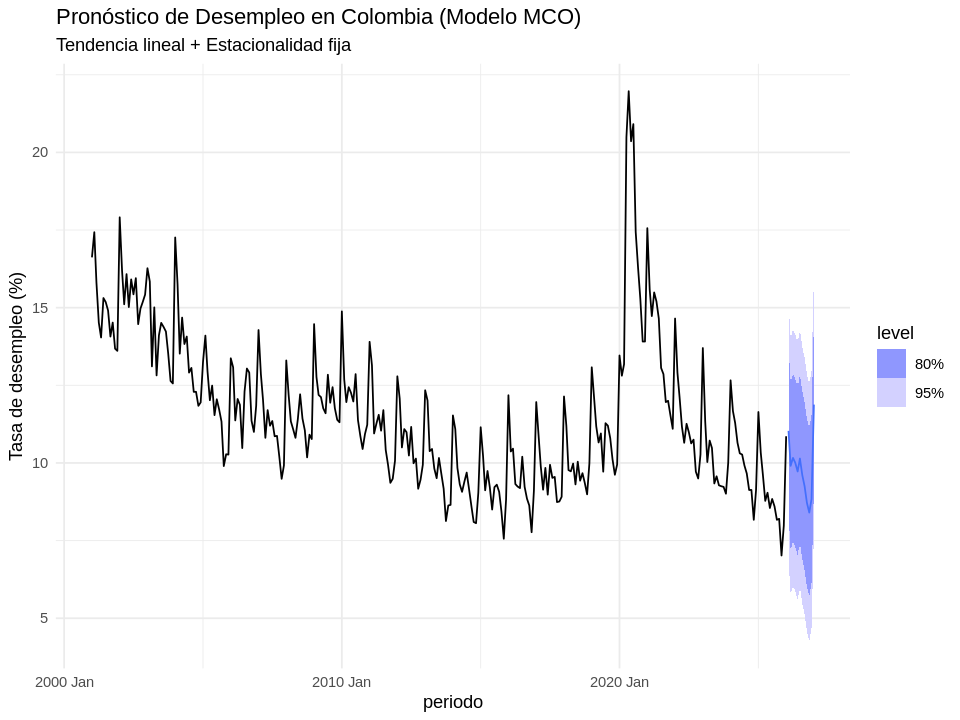

In [17]:
# Ajustar el modelo usando TSLM (Time Series Linear Model - MCO para series de tiempo)
fit_mco <- desempleo |>
  model(
    mco_lineal = TSLM(tasa_desempleo ~ trend() + season())
  )

# Pronostico
pronostico <- forecast(fit_mco, h= 12) # 12 meses

pronostico |>
  autoplot(desempleo) +
  labs(title = "Pronóstico de Desempleo en Colombia (Modelo MCO)",
       subtitle = "Tendencia lineal + Estacionalidad fija",
       y = "Tasa de desempleo (%)") +
  theme_minimal()

In [19]:
# 3. Reporte del modelo
report(fit_mco)

Series: tasa_desempleo 
Model: TSLM 

Residuals:
    Min      1Q  Median      3Q     Max 
-2.7417 -1.2971 -0.4949  0.6245 11.1379 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    15.472645   0.453107  34.148  < 2e-16 ***
trend()        -0.011480   0.001366  -8.407 1.97e-15 ***
season()year2  -0.971829   0.576312  -1.686 0.092823 .  
season()year3  -2.086749   0.576298  -3.621 0.000347 ***
season()year4  -1.820469   0.576286  -3.159 0.001752 ** 
season()year5  -1.965790   0.576278  -3.411 0.000739 ***
season()year6  -2.233510   0.576273  -3.876 0.000132 ***
season()year7  -1.806431   0.576272  -3.135 0.001898 ** 
season()year8  -2.325751   0.576273  -4.036 6.98e-05 ***
season()year9  -2.681472   0.576278  -4.653 4.99e-06 ***
season()year10 -3.193992   0.576286  -5.542 6.74e-08 ***
season()year11 -3.500113   0.576298  -6.073 3.95e-09 ***
season()year12 -3.051833   0.576312  -5.295 2.36e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’

In [27]:
# Modelo solo tendencia
fit_mco <- desempleo |>
  model(
    mco_stl = TSLM(tasa_desempleo ~ trend() + season()),
    mco_stl_covid = TSLM(tasa_desempleo ~ trend() + season() + I(periodo == yearmonth("2020-03-01"))),
    mco_trend = TSLM(tasa_desempleo ~ trend())
  )

# comparar modelos con criterios
glance(fit_mco) |>
  select(.model, adj_r_squared, AIC, BIC)


.model,adj_r_squared,AIC,BIC
<chr>,<dbl>,<dbl>,<dbl>
mco_stl,0.2919962,448.9923,500.8918
mco_stl_covid,0.2931732,449.4445,505.0512
mco_trend,0.1712402,485.6765,496.7978


In [29]:
# Medicion del redimiento del pronostico
accuracy(fit_mco) |>
  select(.model, MAE, RMSE, MAPE, MASE)

.model,MAE,RMSE,MAPE,MASE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
mco_stl,1.399139,2.012389,11.70681,1.117826
mco_stl_covid,1.388562,2.007222,11.61617,1.109376
mco_trend,1.613400,2.218441,13.78263,1.289007


In [36]:
# Validación train (80%) - test pronostico (20%)
index_cut <- floor(nrow(desempleo) * 0.8)
index_train <- seq(1, index_cut)
index_test <- seq(index_cut + 1, nrow(desempleo))

# set train
desempleo_train <- desempleo[index_train, ]
desempleo_test <- desempleo[index_test, ]

# Entrenar el modelo
fit_mco_train <- desempleo_train |>
  model(
    mco_stl = TSLM(tasa_desempleo ~ trend() + season()),
    mco_stl_covid = TSLM(tasa_desempleo ~ trend() + season() + I(periodo == yearmonth("2020-03-01"))),
    mco_trend = TSLM(tasa_desempleo ~ trend())
  )

# Prediccion de los modelos
h_pronostico <- length(index_test)
predict_mco_model <- forecast(fit_mco_train, h = h_pronostico)

# Comparar el rendimiento en el set test
accuracy(predict_mco_model, desempleo_test) |>
  select(.model, MAE, RMSE, MAPE, MASE)

.model,MAE,RMSE,MAPE,MASE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
mco_stl,1.451266,2.044765,11.86903,NaN
mco_stl_covid,1.492868,2.087271,12.22151,NaN
mco_trend,1.680093,2.386559,13.64758,NaN


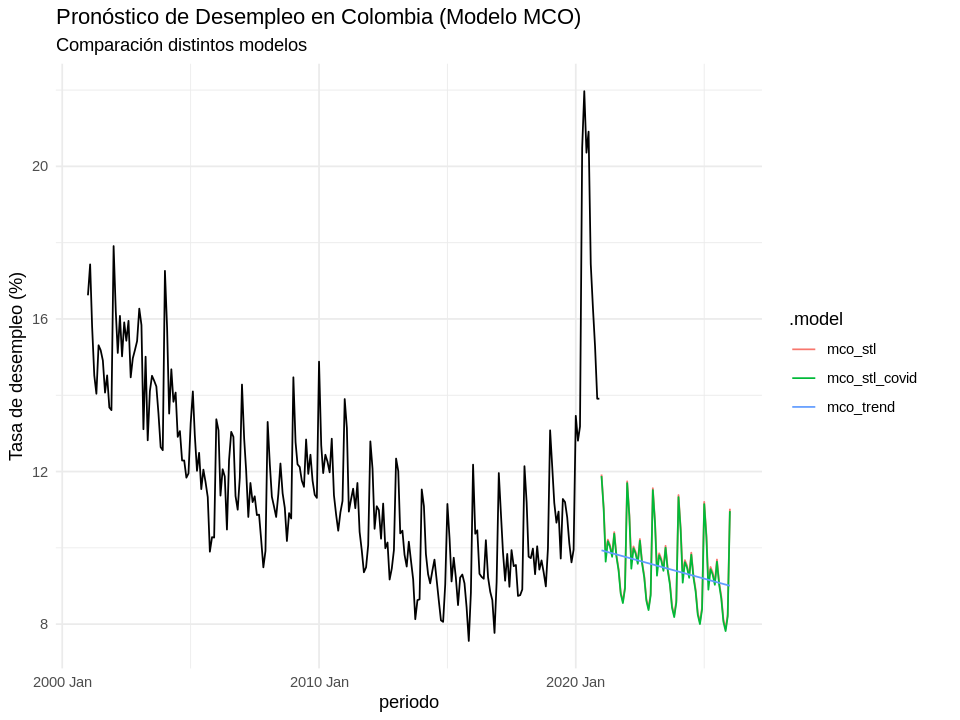

In [43]:
# Graficos pronostico train - test
predict_mco_model |>
  autoplot(desempleo_train, level = NULL) +
  labs(title = "Pronóstico de Desempleo en Colombia (Modelo MCO)",
       subtitle = "Comparación distintos modelos",
       y = "Tasa de desempleo (%)") +
  theme_minimal()

Warning message:
“`gg_tsresiduals()` was deprecated in feasts 0.4.2.
ℹ Please use `ggtime::gg_tsresiduals()` instead.
ℹ Graphics functions have been moved to the {ggtime} package. Please use
  `library(ggtime)` instead.”


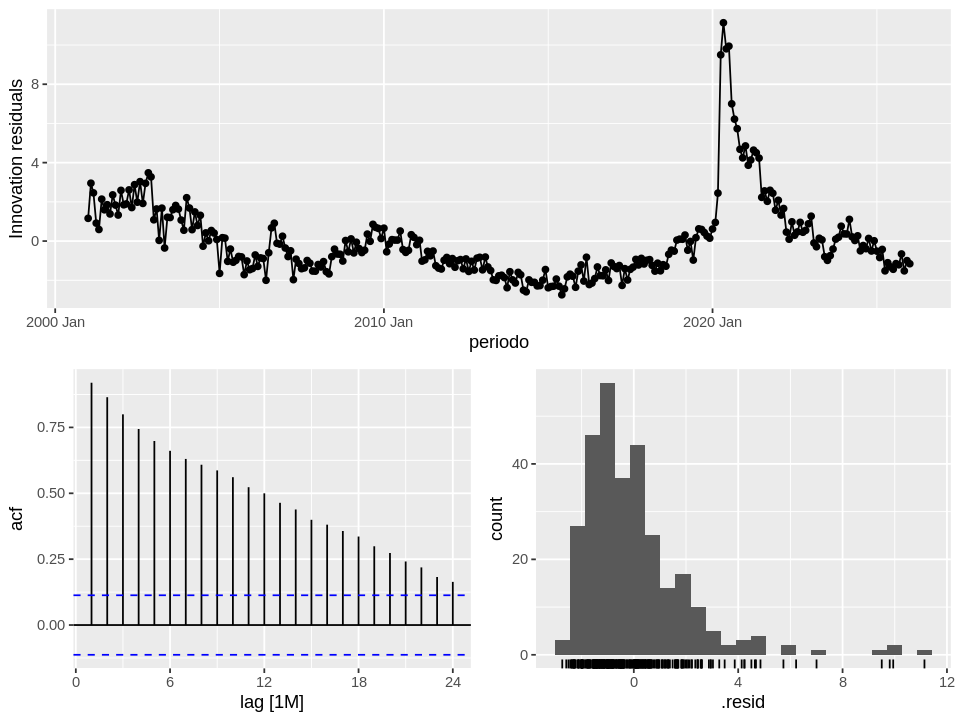

In [20]:
# 4. Residuos del modelo MCO
fit_mco |> gg_tsresiduals()